X shape: (100, 3)
y shape: (100, 1)
theta shape: (3, 1)
Iteration 0 - Gradient:
 [[ 0.07      ]
 [-0.25021991]
 [-0.26185338]]
Iteration 0 - Theta after:
 [[-0.0035    ]
 [ 0.012511  ]
 [ 0.01309267]]
Iteration 0 | Cost: 0.6863831361266738
Iteration 10000 - Gradient:
 [[ 0.00019112]
 [-0.00034924]
 [-0.00041669]]
Iteration 10000 - Theta after:
 [[-1.57280703]
 [ 3.49112233]
 [ 3.87598095]]
Iteration 10000 | Cost: 0.2330236558426171
Iteration 20000 - Gradient:
 [[ 1.00792646e-05]
 [-1.84505509e-05]
 [-2.20382364e-05]]
Iteration 20000 - Theta after:
 [[-1.60325403]
 [ 3.54680776]
 [ 3.94245803]]
Iteration 20000 | Cost: 0.2329959696209614
Iteration 30000 - Gradient:
 [[ 5.55769126e-07]
 [-1.01745877e-06]
 [-1.21537257e-06]]
Iteration 30000 - Theta after:
 [[-1.60489608]
 [ 3.54981376]
 [ 3.94604865]]
Iteration 30000 | Cost: 0.2329958899331853
Iteration 40000 - Gradient:
 [[ 3.07184409e-08]
 [-5.62372262e-08]
 [-6.71765789e-08]]
Iteration 40000 - Theta after:
 [[-1.60498674]
 [ 3.54997972]

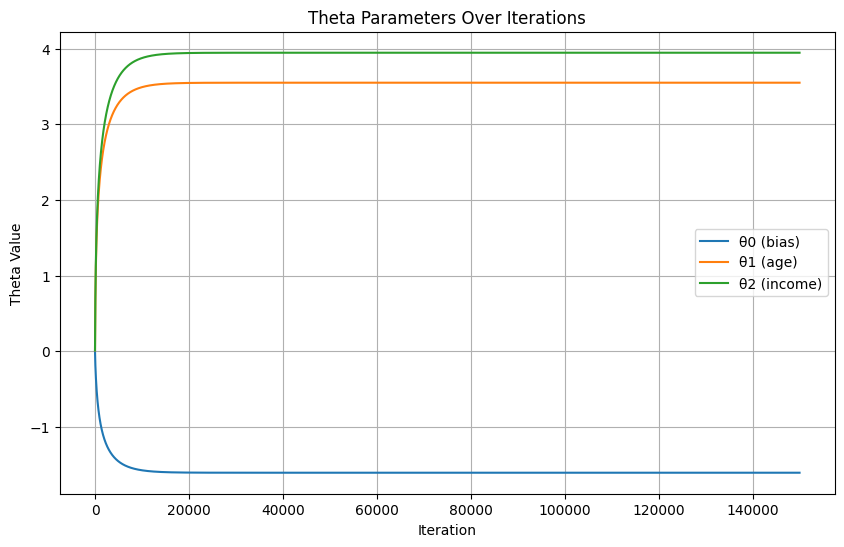

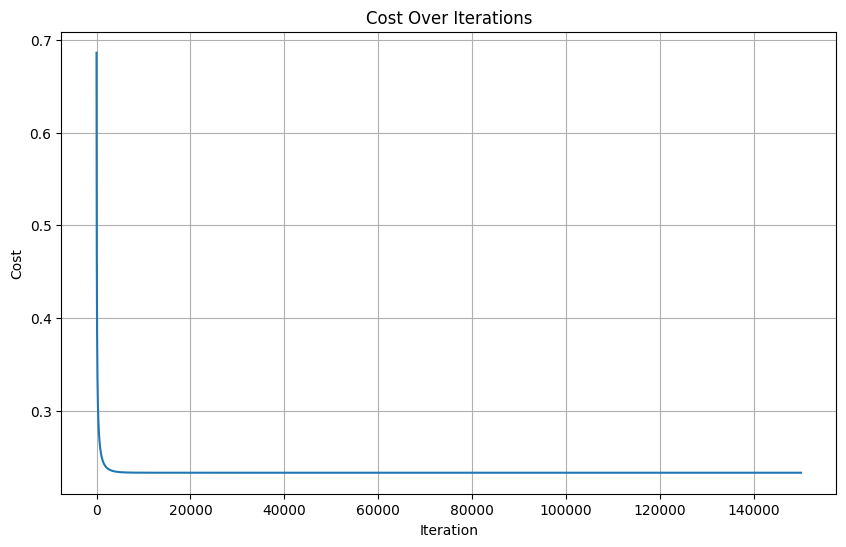

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Cost function
def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    cost = (-1 / m) * (y.T @ np.log(h + 1e-10) + (1 - y).T @ np.log(1 - h + 1e-10))
    return cost.item()

# Gradient descent function with theta history
def gradient_descent(X, y, theta, alpha, num_iterations):
    m = len(y)
    cost_history = []
    theta_history = []  # To store theta at each iteration
    
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("theta shape:", theta.shape)
    
    for i in range(num_iterations):
        h = sigmoid(X @ theta)
        gradient = (1 / m) * X.T @ (h - y)
        
        theta -= alpha * gradient
        theta_history.append(theta.copy())  # Store a copy of theta
        
        if i % 10000 == 0:
            print(f"Iteration {i} - Gradient:\n", gradient)
            print(f"Iteration {i} - Theta after:\n", theta)
        
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        if i % 10000 == 0:
            print(f"Iteration {i} | Cost: {cost}")
    
    return theta, cost_history, theta_history

# Data generation
np.random.seed(0)
m = 100
age = np.random.uniform(18, 70, m)
income = np.random.uniform(20, 100, m)
labels = (age > 35) & (income > 50)
y_train = labels.astype(int).reshape(-1, 1)  # Shape: (m, 1)
X_train = np.c_[np.ones(m), age, income]     # Shape: (m, 3)

# Normalize features (excluding bias column)
X_train[:, 1:] = (X_train[:, 1:] - X_train[:, 1:].mean(axis=0)) / X_train[:, 1:].std(axis=0)

# Initialize parameters
theta_initial = np.zeros((X_train.shape[1], 1))  # Shape: (3, 1)
alpha = 0.05  # Learning rate
iterations = 150000

# Run gradient descent
theta_learned, cost_history, theta_history = gradient_descent(X_train, y_train, theta_initial, alpha, iterations)
print(f"Learned theta:\n{theta_learned}")

# Convert theta_history to a numpy array for easier plotting (shape: iterations x 3)
theta_history = np.array(theta_history).squeeze()  # Shape: (1000, 3)

# Plot theta over iterations
plt.figure(figsize=(10, 6))
plt.plot(theta_history[:, 0], label='θ0 (bias)')
plt.plot(theta_history[:, 1], label='θ1 (age)')  # Fixed line
plt.plot(theta_history[:, 2], label='θ2 (income)')
plt.xlabel('Iteration')
plt.ylabel('Theta Value')
plt.title('Theta Parameters Over Iterations')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot cost history for reference
plt.figure(figsize=(10, 6))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Over Iterations')
plt.grid(True)
plt.show()

In [105]:
# Assuming these are from your training run
theta_learned = np.array([[-1.60325163], [3.54680336], [3.94245279]])
age_mean, age_std = np.mean(age), np.std(age)
income_mean, income_std = np.mean(income), np.std(income)

# Simple prediction function
def get_probability(age, income):
    age_norm = (age - age_mean) / age_std
    income_norm = (income - income_mean) / income_std
    X_test = np.array([1, age_norm, income_norm]).reshape(3, 1)
    return sigmoid(X_test.T @ theta_learned).item()

# Test variables
test_age = 27
test_income = 27

# Get probability
prob = get_probability(test_age, test_income)
print(f"Probability for Age = {test_age}, Income = {test_income}: {prob:.4f}")

Probability for Age = 27, Income = 27: 0.0000


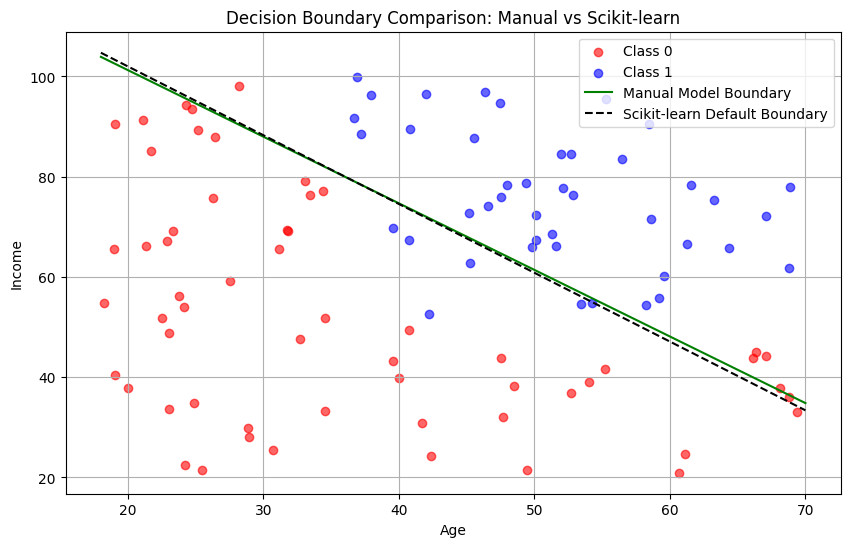

Manual Model: Age = 58, Income = 50, Probability = 0.4657
Scikit-learn: Age = 58, Income = 50, Probability = 0.5039


In [108]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Sigmoid function (for manual model)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Data generation (same as before)
np.random.seed(0)
m = 100
age = np.random.uniform(18, 70, m)
income = np.random.uniform(20, 100, m)
labels = (age > 35) & (income > 50)
y_train = labels.astype(int)
X_train = np.c_[age, income]

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Theta values
manual_theta = np.array([-1.60325163, 3.54680336, 3.94245279])  # Manual model
sklearn_theta = np.array([-0.8840, 2.07815919, 2.23635277])    # Scikit-learn default

# Function to compute decision boundary (income as a function of age)
def compute_boundary(age_range, theta, scaler):
    age_norm = (age_range - scaler.mean_[0]) / scaler.scale_[0]
    # Solve: theta0 + theta1 * age_norm + theta2 * income_norm = 0
    income_norm = (-theta[0] - theta[1] * age_norm) / theta[2]
    income = income_norm * scaler.scale_[1] + scaler.mean_[1]
    return income

# Generate age range for plotting
age_range = np.linspace(18, 70, 100)

# Compute boundaries
manual_boundary = compute_boundary(age_range, manual_theta, scaler)
sklearn_boundary = compute_boundary(age_range, sklearn_theta, scaler)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(age[y_train == 0], income[y_train == 0], c='red', label='Class 0', alpha=0.6)
plt.scatter(age[y_train == 1], income[y_train == 1], c='blue', label='Class 1', alpha=0.6)
plt.plot(age_range, manual_boundary, 'g-', label='Manual Model Boundary')
plt.plot(age_range, sklearn_boundary, 'k--', label='Scikit-learn Default Boundary')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Decision Boundary Comparison: Manual vs Scikit-learn')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Print probabilities at a test point for both models
def get_manual_prob(age, income, theta, scaler):
    X_test = np.array([1, (age - scaler.mean_[0]) / scaler.scale_[0], (income - scaler.mean_[1]) / scaler.scale_[1]])
    return sigmoid(X_test @ theta)

test_age, test_income = 58, 50
manual_prob = get_manual_prob(test_age, test_income, manual_theta, scaler)
sklearn_prob = get_manual_prob(test_age, test_income, sklearn_theta, scaler)
print(f"Manual Model: Age = {test_age}, Income = {test_income}, Probability = {manual_prob:.4f}")
print(f"Scikit-learn: Age = {test_age}, Income = {test_income}, Probability = {sklearn_prob:.4f}")